In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load dataset
data = pd.read_csv("housing.csv")

# Drop missing values
data = data.dropna()

# Drop 'Address' since it's categorical and not useful for regression here
X = data.drop(['Price', 'Address'], axis=1)
y = data['Price']

# Scale features
scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build MLP model
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # Regression output

# Compile with regression loss
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
model.fit(X_train, y_train, epochs=50, batch_size=10, verbose=1)

# Evaluate
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MSE:", loss)
print("Test MAE:", mae)


Epoch 1/50


/home/cse/myenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-02 12:12:45.982613: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 567us/step - loss: 1636552146944.0000 - mae: 1229442.2500
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step - loss: 1631348719616.0000 - mae: 1227525.8750
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - loss: 1613345062912.0000 - mae: 1221044.6250
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step - loss: 1577501065216.0000 - mae: 1208178.8750
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step - loss: 1521344315392.0000 - mae: 1187861.0000
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step - loss: 1444417765376.0000 - mae: 1159407.3750
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step - loss: 1348079452160.0000 - mae: 1122699.7500
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step - loss: 1234980962304.0000 - mae: 1077684.8750
Epoch 9/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step - loss: 1108693745664.0000 - mae: 1024452.1875
Epoch 10/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - loss: 973927940096.0000 - mae: 963531.5000 
E

Epoch 1/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 11171930112.0000 - mae: 84655.7500 - val_loss: 10387269632.0000 - val_mae: 81015.2734
Epoch 2/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step - loss: 11117527040.0000 - mae: 84486.0703 - val_loss: 10361891840.0000 - val_mae: 80922.2656
Epoch 3/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step - loss: 11077516288.0000 - mae: 84376.4531 - val_loss: 10338108416.0000 - val_mae: 80894.2188
Epoch 4/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - loss: 11034423296.0000 - mae: 84230.6797 - val_loss: 10284219392.0000 - val_mae: 80651.4062
Epoch 5/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 748us/step - loss: 11001869312.0000 - mae: 84120.3125 - val_loss: 10262951936.0000 - val_mae: 80615.3750
Epoch 6/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 760us/step - loss: 10973560832.0000 - mae: 84037.1562 - val_loss: 10252860416.0000 - val_mae: 80606.4844
Epoch 7/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - loss: 10936903680.0000 - mae: 83929.5391 - val_loss: 102

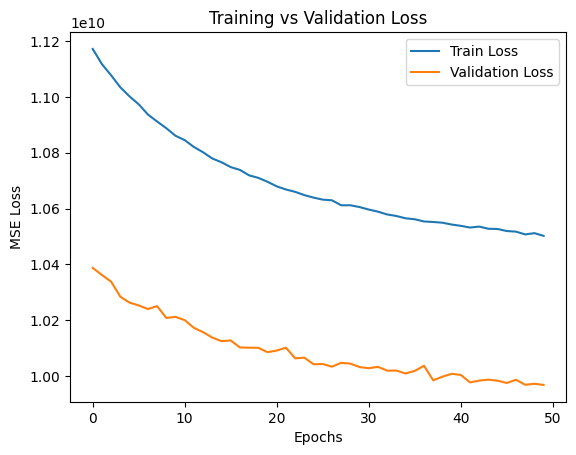

In [7]:
import matplotlib.pyplot as plt

# Train and capture history
history = model.fit(X_train, y_train, epochs=50, batch_size=10, verbose=1, validation_split=0.2)

# Plot training & validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()


In [2]:
pip install tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 5.5 MB/s eta 0:00:000m eta 0:00:010:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 12.6 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 12.6 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 6.6 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 6.7 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 5.8 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 5.3 MB/s eta 0:00:006.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 6.5 MB/s eta 0:00:00m et